In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from eheatmap import eheatmap

In [2]:
import eheatmap

In [3]:
# ============================================================
# 1. Generate data with 3 distinct clusters
# ============================================================
np.random.seed(42)

n_rows, n_cols = 30, 20
cluster1_rows, cluster2_rows, cluster3_rows = 10, 10, 10
group1_cols, group2_cols, group3_cols = 7, 7, 6

data = np.zeros((n_rows, n_cols))

# Cluster 1: High expression in the first group of samples
for i in range(cluster1_rows):
    data[i, :group1_cols] = np.random.normal(2.0, 0.3, group1_cols)
    data[i, group1_cols:] = np.random.normal(-1.0, 0.3, n_cols - group1_cols)

# Cluster 2: High expression in the second group of samples
for i in range(cluster1_rows, cluster1_rows + cluster2_rows):
    data[i, :group1_cols] = np.random.normal(-1.0, 0.3, group1_cols)
    data[i, group1_cols:group1_cols+group2_cols] = np.random.normal(2.0, 0.3, group2_cols)
    data[i, group1_cols+group2_cols:] = np.random.normal(-1.0, 0.3, group3_cols)

# Cluster 3: High expression in the third group of samples
for i in range(cluster1_rows + cluster2_rows, n_rows):
    data[i, :group1_cols+group2_cols] = np.random.normal(-1.0, 0.3, group1_cols+group2_cols)
    data[i, group1_cols+group2_cols:] = np.random.normal(2.0, 0.3, group3_cols)


In [5]:
df = pd.DataFrame(
    data,
    index=[f"Gene_{i+1}" for i in range(n_rows)],
    columns=[f"Sample_{i+1}" for i in range(n_cols)]
)

In [6]:
# ============================================================
# 2. Generate row and column annotations
# ============================================================
row_anno = pd.DataFrame({
    "Group": [f"Group_{np.random.choice(['A', 'B', 'C'])}" for _ in range(n_rows)],
    "Score": np.random.uniform(0, 100, n_rows),
    "Type": [np.random.choice(["Type1", "Type2", "Type3"]) for _ in range(n_rows)]
}, index=df.index)

col_anno = pd.DataFrame({
    "Treatment": [np.random.choice(["Control", "Drug_A", "Drug_B"]) for _ in range(n_cols)],
    "Time": [f"T{i}" for i in np.random.randint(1, 5, n_cols)],
    "Value": np.random.uniform(0, 1, n_cols)
}, index=df.columns)


In [7]:
# ============================================================
# 3. CNS-level color schemes (ColorBrewer)
# ============================================================
annotation_colors = {
    # Row Annotations
    "Group": {
        "Group_A": "#E41A1C",  # Red
        "Group_B": "#377EB8",  # Blue
        "Group_C": "#4DAF4A",  # Green
    },
    "Type": {
        "Type1": "#FF7F00",    # Orange
        "Type2": "#984EA3",    # Purple
        "Type3": "#FFFF33",    # Yellow
    },
    # Column Annotations
    "Treatment": {
        "Control": "#999999",   # Grey (Control group)
        "Drug_A": "#66C2A5",    # Teal
        "Drug_B": "#FC8D62",    # Coral
    },
    "Time": {
        "T1": "#8DA0CB",       # Light Blue
        "T2": "#E78AC3",       # Pink
        "T3": "#A6D854",       # Light Green
        "T4": "#FFD92F",       # Golden Yellow
    },
}

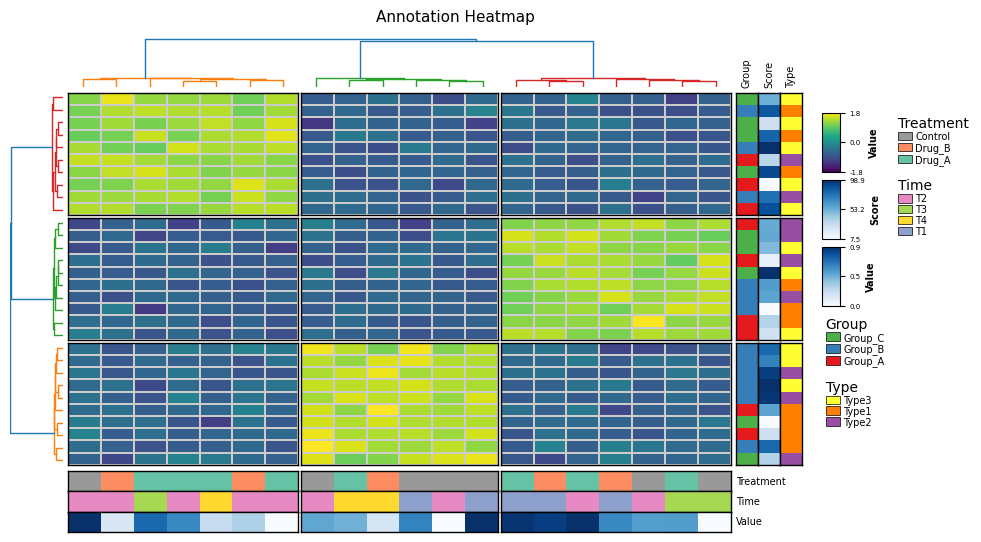

In [13]:
# ============================================================
# 4. Plot the Heatmap
# ============================================================
fig = eheatmap(
    df,
    scale="row",                    # Row Z-score normalization
    cutree_rows=3,                  # Split rows into 3 clusters
    cutree_cols=3,                  # Split columns into 3 groups
    annotation_row=row_anno,        # Row annotations
    annotation_col=col_anno,        # Column annotations
    annotation_colors=annotation_colors,  # Custom color mapping
    color="viridis",                # CNS-recommended colormap
    center=0,                       # Color center point
    border_color="grey80",          # Cell border color
    fontsize=9,
    dendrogram_linewidth=1,
    treeheight_col=40,
    treeheight_row=20,
    dendrogram_colors="colorful",
    split_border_color="black",     # Split line color
    split_border_width=1.0,
    legend=True,
    annotation_legend=True,
    main="Annotation Heatmap"
)
